# Life Expectancy Prediction: End-to-End Machine Learning Project

This notebook performs an end-to-end analysis and prediction of life expectancy using the Life Expectancy Data.csv dataset. We will cover data loading, EDA, preprocessing, modeling, and evaluation.

## 1. Load the Dataset

Download the dataset from the Kaggle link (https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who) and load it into the Python environment using pandas.

In [26]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('Life Expectancy Data.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(df.head())

Dataset loaded successfully!
Shape: (2938, 22)
       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   Polio  Total expenditure  Diphtheria

## 2. Exploratory Data Analysis (EDA) and Visualizations

Perform EDA including summary statistics, data types, missing values, and create visualizations such as histograms, scatter plots, and correlation heatmaps using libraries like matplotlib and seaborn.

Data Types:
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

Summary Statistics:
       

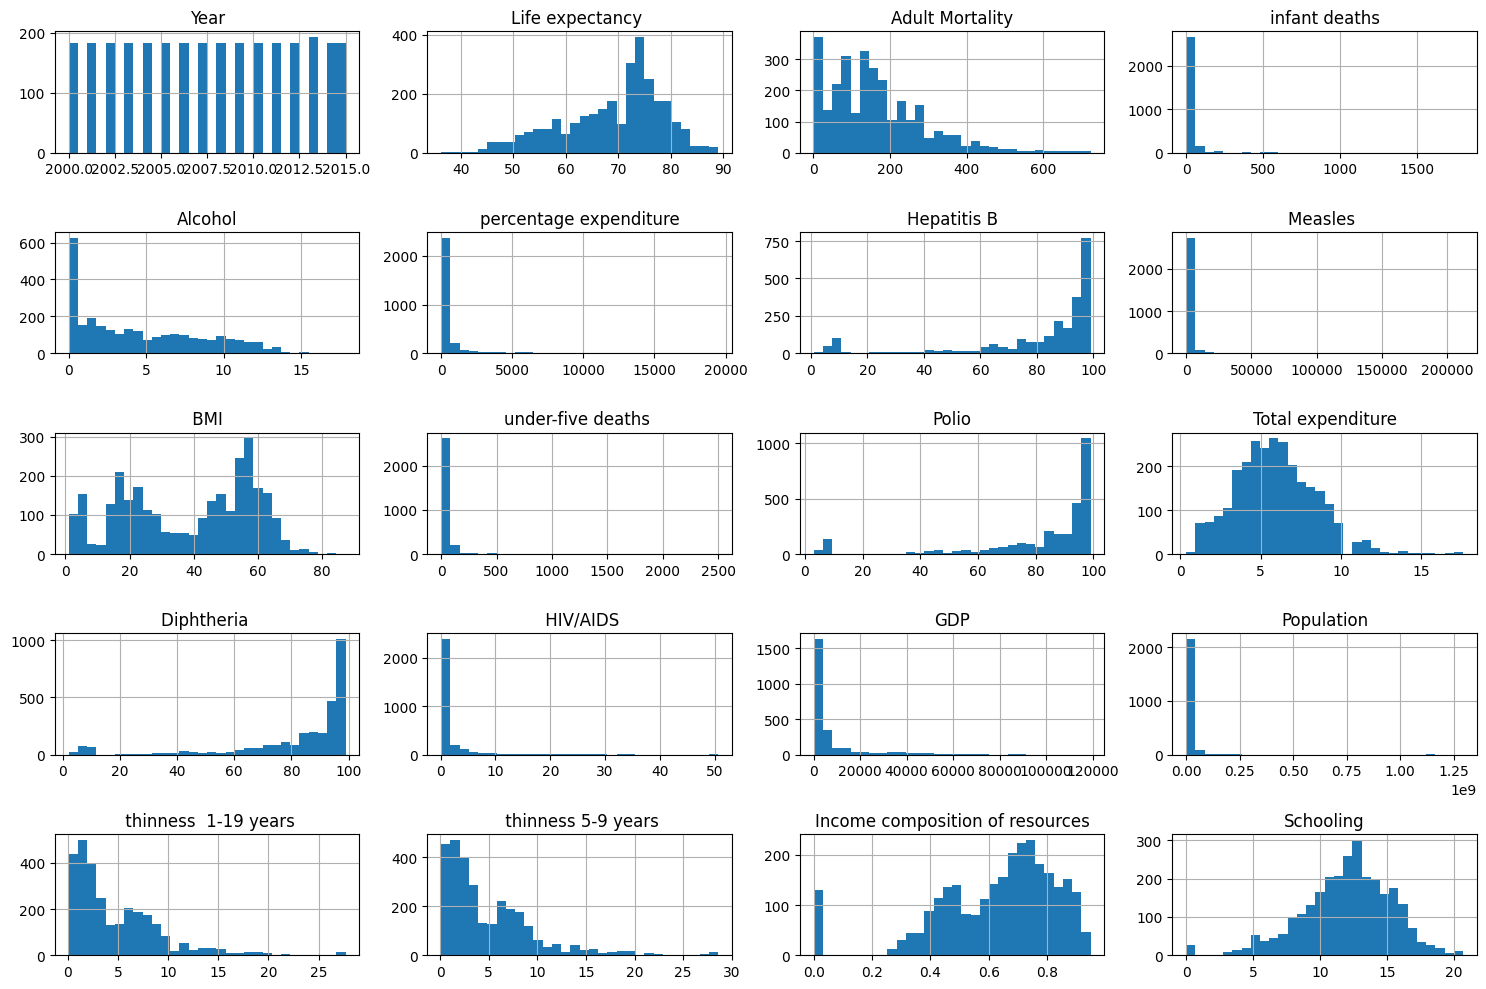

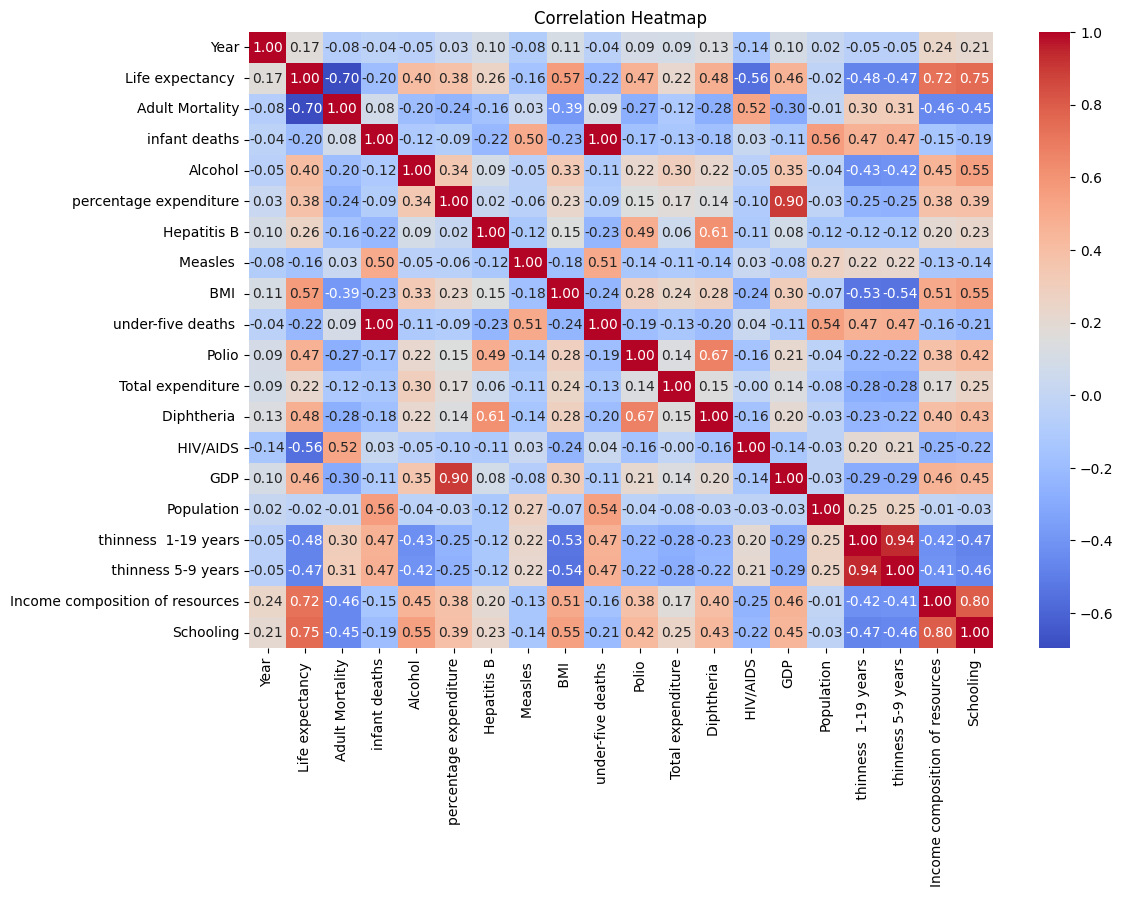

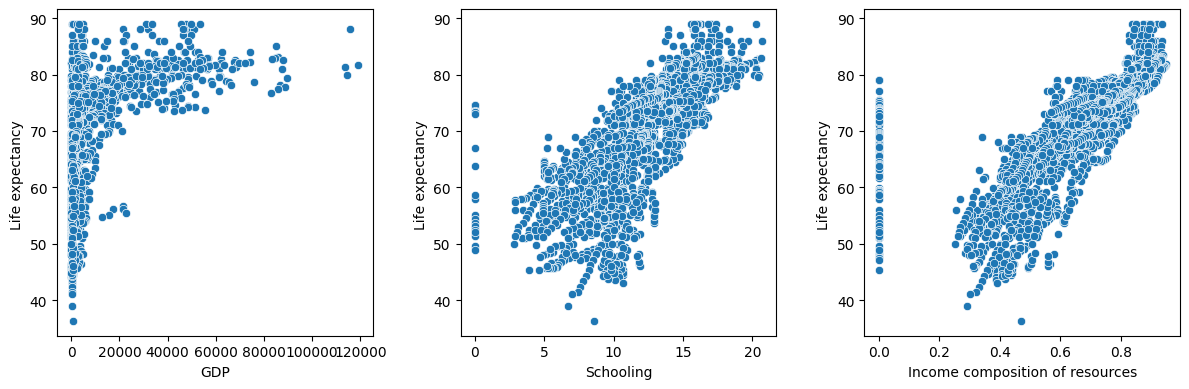

In [27]:
# Basic info
print("Data Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Visualizations
# Histograms for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Scatter plot of Life expectancy vs some key features
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(x='GDP', y='Life expectancy ', data=df)
plt.subplot(1, 3, 2)
sns.scatterplot(x='Schooling', y='Life expectancy ', data=df)
plt.subplot(1, 3, 3)
sns.scatterplot(x='Income composition of resources', y='Life expectancy ', data=df)
plt.tight_layout()
plt.show()

## 3. Check Distributions and Skewness, Apply Transformations

Analyze distributions and skewness of variables using statistical tests and plots, then apply transformations like log or Box-Cox if needed to normalize data.

Skewness of numerical features:
Year                               -0.006406
Life expectancy                    -0.638278
Adult Mortality                     1.173768
infant deaths                       9.781965
Alcohol                             0.589240
percentage expenditure              4.649676
Hepatitis B                        -1.929631
Measles                             9.436511
 BMI                               -0.219198
under-five deaths                   9.490216
Polio                              -2.096975
Total expenditure                   0.618343
Diphtheria                         -2.071688
 HIV/AIDS                           5.393357
GDP                                 3.204723
Population                         15.905790
 thinness  1-19 years               1.710587
 thinness 5-9 years                 1.776506
Income composition of resources    -1.143143
Schooling                          -0.602111
dtype: float64


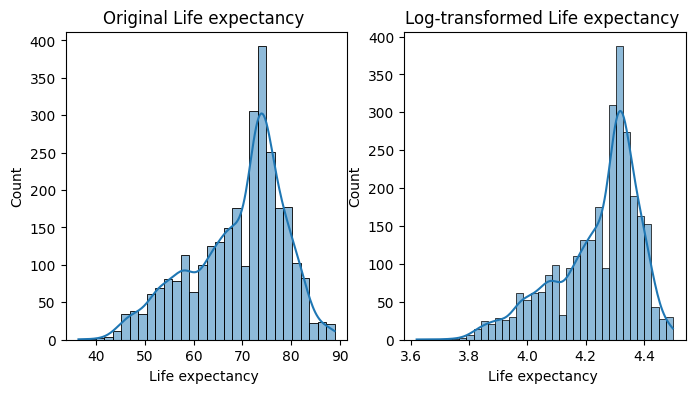

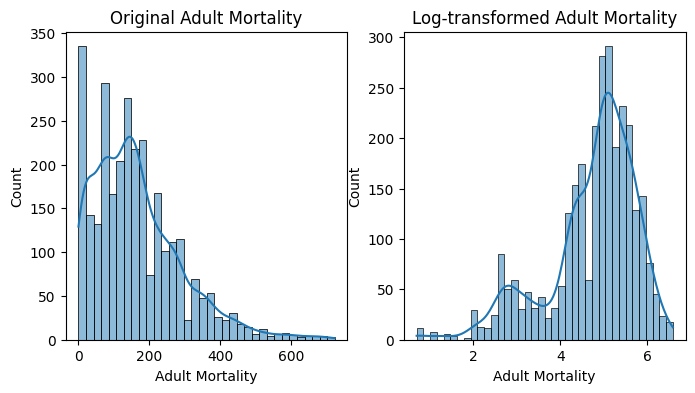

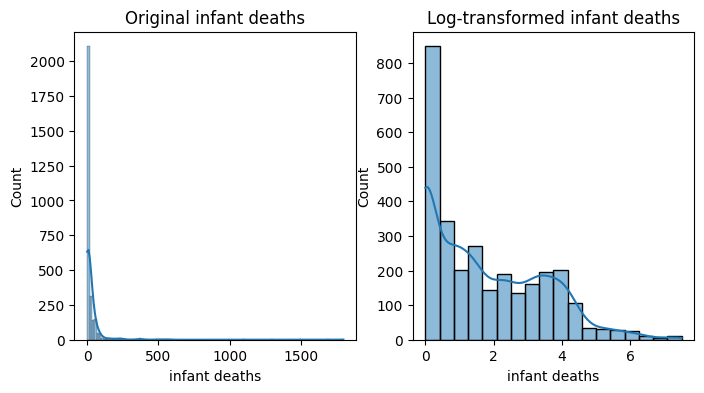

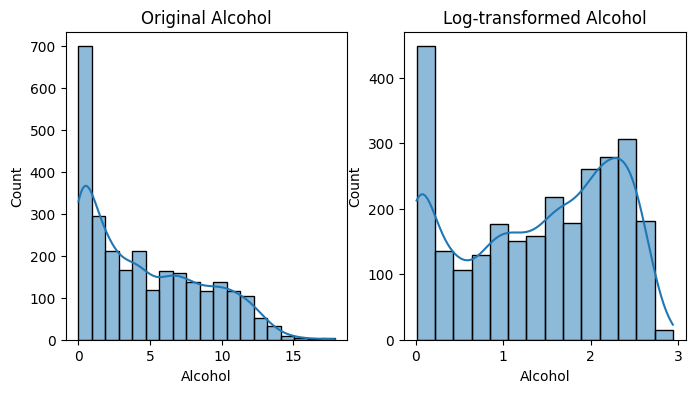

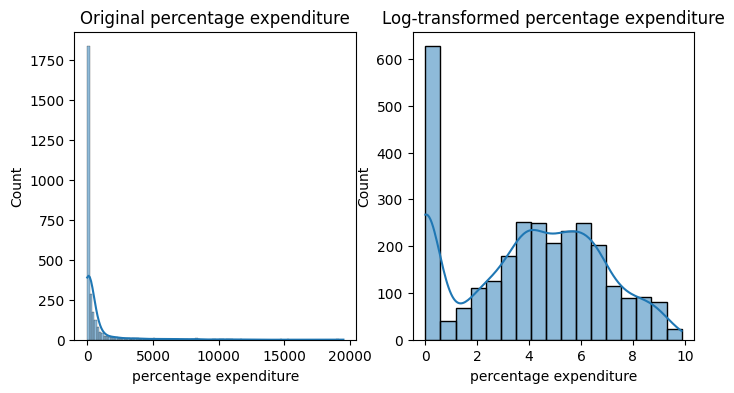

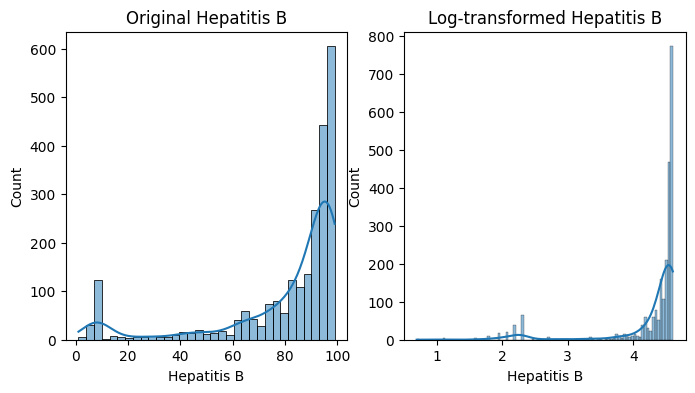

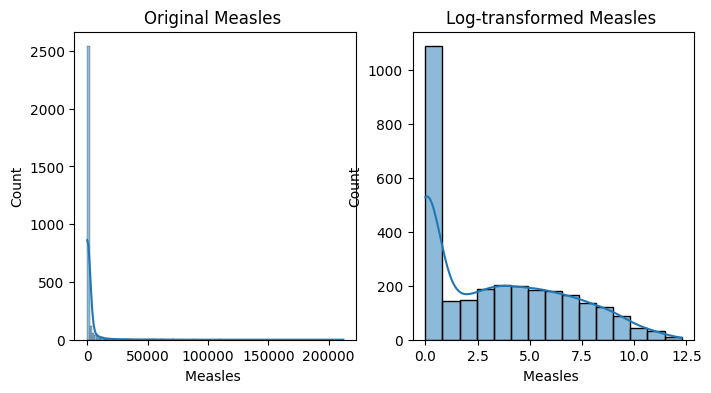

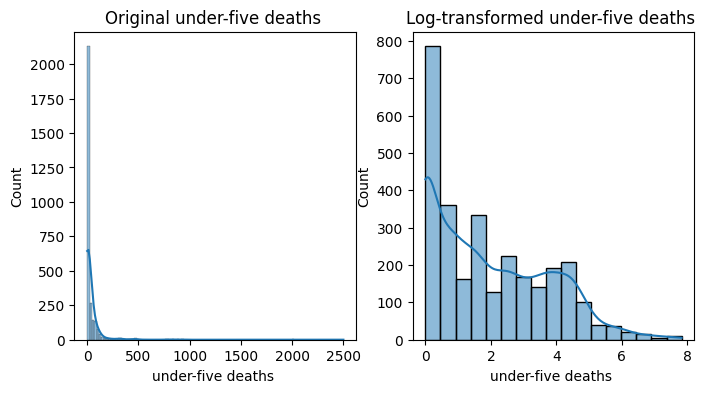

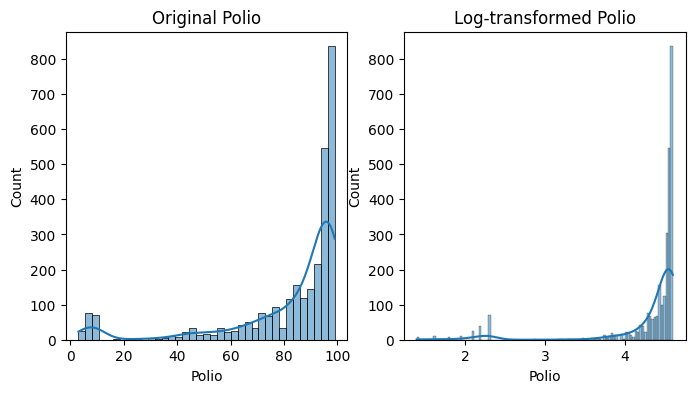

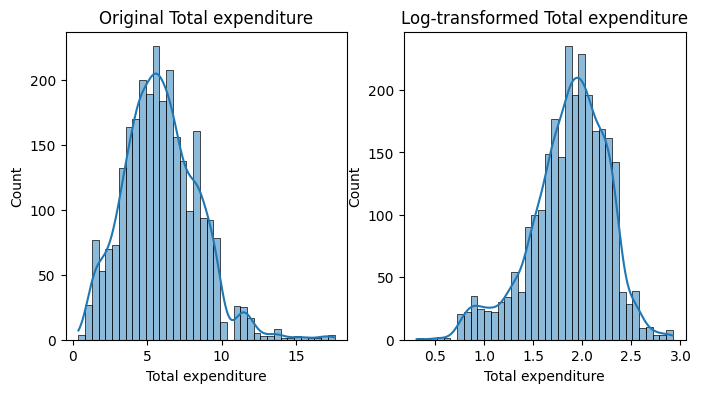

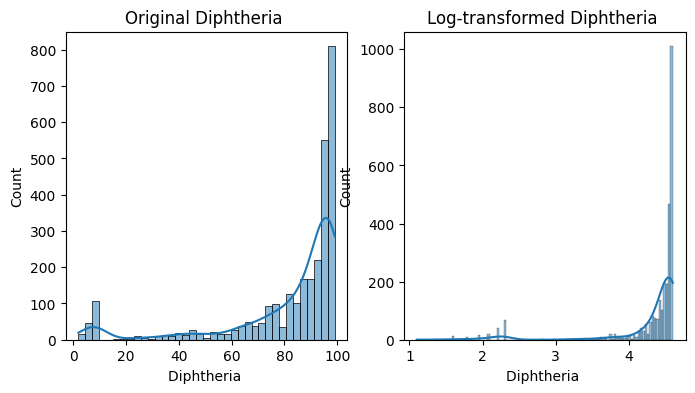

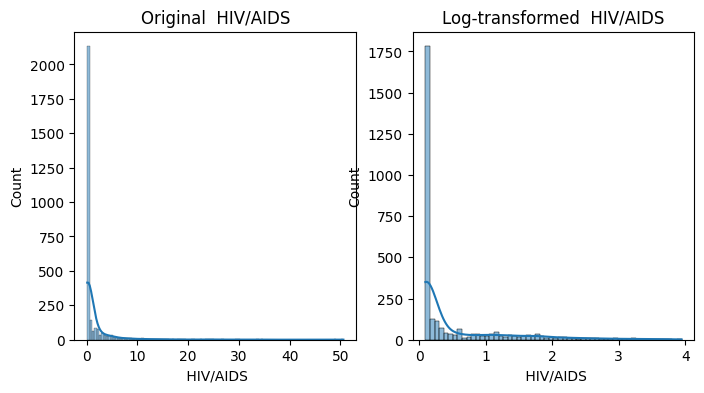

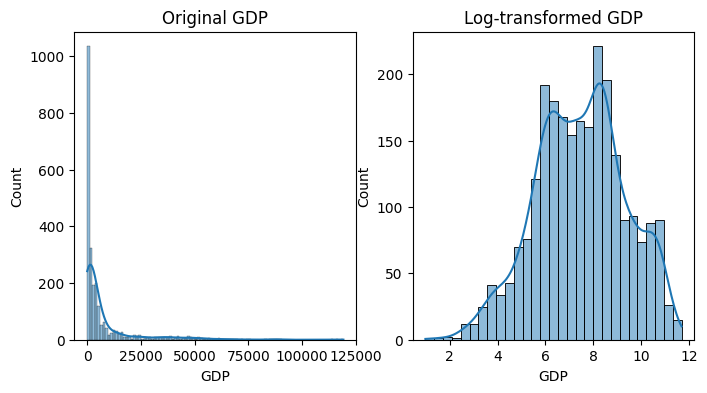

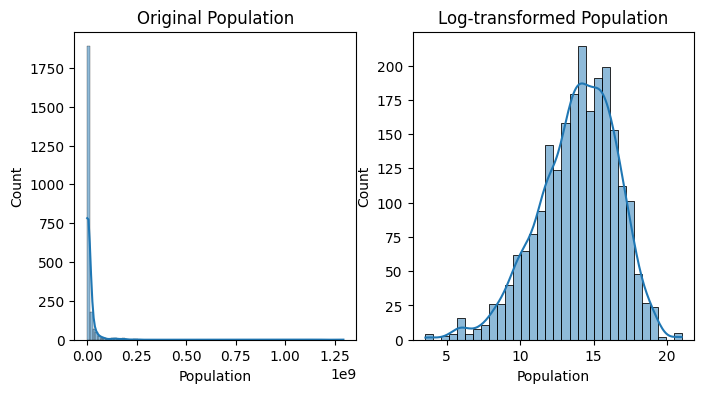

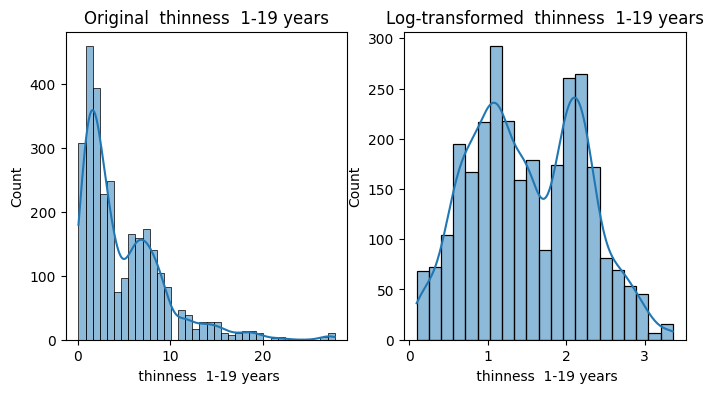

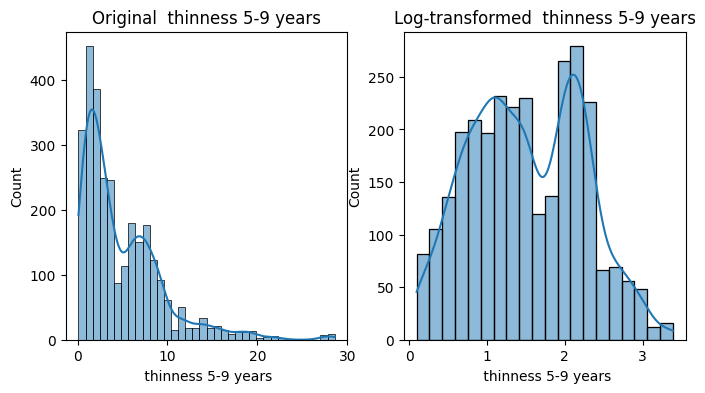

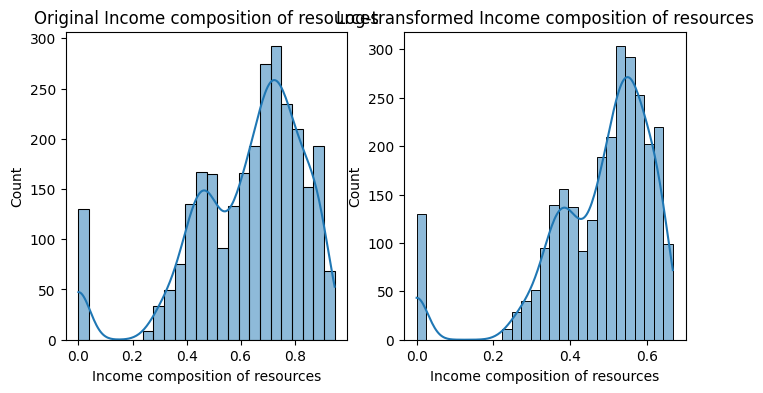

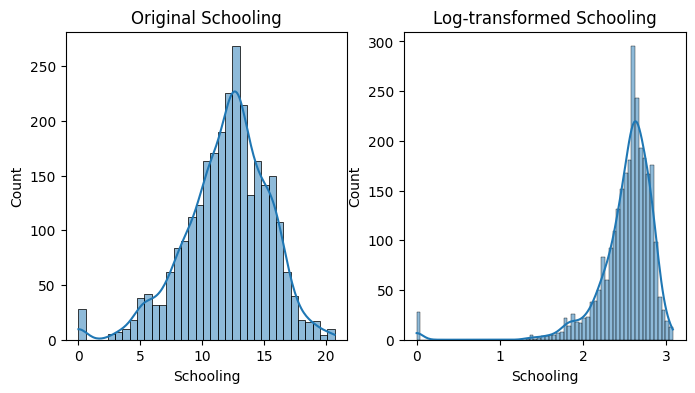

Transformations applied to skewed features.


In [28]:
# Check skewness
from scipy.stats import skew

skewness = df[numerical_cols].apply(lambda x: skew(x.dropna()))
print("Skewness of numerical features:")
print(skewness)

# Plot distributions for skewed features
skewed_features = skewness[abs(skewness) > 0.5].index
for col in skewed_features:
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Original {col}')
    plt.subplot(1, 2, 2)
    sns.histplot(np.log1p(df[col]), kde=True)
    plt.title(f'Log-transformed {col}')
    plt.show()

# Apply log transformation to highly skewed features
df_transformed = df.copy()
for col in skewed_features:
    if (df[col] > 0).all():  # Ensure positive values
        df_transformed[col] = np.log1p(df[col])

print("Transformations applied to skewed features.")

## 4. Check and Treat Outliers, Apply Feature Scaling

Detect outliers using methods like IQR or Z-score, treat them by removal or capping, and apply feature scaling techniques such as standardization or normalization using scikit-learn.

In [29]:
# Handle missing values
df_clean = df_transformed.fillna(df_transformed.median(numeric_only=True))

# Detect outliers using IQR
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[col] < lower_bound) | (data[col] > upper_bound)]

outliers = {}
for col in numerical_cols:
    if col != 'Life expectancy ':  # Exclude target
        outliers[col] = detect_outliers_iqr(df_clean, col).shape[0]

print("Number of outliers per feature:")
print(outliers)

# Remove outliers (simple approach: remove rows with outliers in any feature)
# For simplicity, cap outliers
for col in numerical_cols:
    if col != 'Life expectancy ':
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_clean[col] = np.clip(df_clean[col], lower_bound, upper_bound)

print("Outliers treated by capping.")

# Feature scaling
scaler = StandardScaler()
features = [col for col in numerical_cols if col != 'Life expectancy ']
df_scaled = df_clean.copy()
df_scaled[features] = scaler.fit_transform(df_clean[features])

print("Feature scaling applied.")

Number of outliers per feature:
{'Year': 0, 'Adult Mortality': 86, 'infant deaths': 315, 'Alcohol': 3, 'percentage expenditure': 389, 'Hepatitis B': 322, 'Measles ': 542, ' BMI ': 0, 'under-five deaths ': 394, 'Polio': 279, 'Total expenditure': 51, 'Diphtheria ': 298, ' HIV/AIDS': 421, 'GDP': 445, 'Population': 452, ' thinness  1-19 years': 100, ' thinness 5-9 years': 99, 'Income composition of resources': 130, 'Schooling': 77}
Outliers treated by capping.
Feature scaling applied.


## 5. Create a Machine Learning Model for Prediction

Build a baseline ML model (e.g., linear regression) to predict life expectancy, including data splitting, training, and initial evaluation using metrics like MSE or R-squared.

In [30]:
# Prepare data for modeling
X = df_scaled[features]
y = df_scaled['Life expectancy ']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline model: Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Baseline Model: Linear Regression")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr)}")
print(f"R2 Score: {r2_score(y_test, y_pred_lr)}")

Baseline Model: Linear Regression
MSE: 12.18642986199246
R2 Score: 0.8593884812453824


## 6. Check and Treat Overfitting

Evaluate the model for overfitting using cross-validation, learning curves, or train-test performance gaps, and apply regularization techniques like Ridge or Lasso if necessary.

In [31]:
# Check for overfitting
train_score = lr.score(X_train, y_train)
test_score = lr.score(X_test, y_test)
print(f"Train R2: {train_score}, Test R2: {test_score}")

# Cross-validation
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
print(f"Cross-validation R2 scores: {cv_scores}")
print(f"Mean CV R2: {cv_scores.mean()}")

# If overfitting (high train, low test), apply regularization
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
print(f"Ridge MSE: {mean_squared_error(y_test, y_pred_ridge)}")
print(f"Ridge R2: {r2_score(y_test, y_pred_ridge)}")

Train R2: 0.8516182142170655, Test R2: 0.8593884812453824
Cross-validation R2 scores: [0.87983408 0.82121387 0.80205708 0.83379356 0.83679794]
Mean CV R2: 0.8347393051820982
Ridge MSE: 12.185446230721055
Ridge R2: 0.8593998307454848


## 7. Compare Supervised ML Algorithms

Implement and compare multiple supervised algorithms including Decision Trees, Random Forest, SVM, and XGBoost, using cross-validation and metrics to select the best model.

In [32]:
# Define models
models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVM': SVR(),
    'XGBoost': XGBRegressor(random_state=42)
}

# Evaluate models
results = {}
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    results[name] = {'MSE': mse, 'R2': r2, 'CV_R2': cv_r2}
    fitted_models[name] = model

# Display results
results_df = pd.DataFrame(results).T
print(results_df)

# Best model
best_model_name = results_df['R2'].idxmax()
best_model = fitted_models[best_model_name]
print(f"\nBest Model: {best_model_name} with R2: {results_df.loc[best_model_name, 'R2']}")

# Save the best model to pickle
import pickle
with open('best_life_expectancy_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"\nBest model ({best_model_name}) saved to 'best_life_expectancy_model.pkl'")

                    MSE        R2     CV_R2
Decision Tree  5.668180  0.934598  0.830531
Random Forest  2.839421  0.967238  0.906185
SVM            8.112990  0.906389  0.849517
XGBoost        3.160285  0.963535  0.907940

Best Model: Random Forest with R2: 0.9672377101594658

Best model (Random Forest) saved to 'best_life_expectancy_model.pkl'
